In [1]:
# %load_ext autoreload
# %autoreload 2
import os, sys

import scanpy as sc
import anndata as ad

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
main_dir = "/home/wergillius/Project/diffuse_differentiate/"

In [ ]:
from scipy import io

In [ ]:
# read the integrated results
integrated_adata = sc.read_h5ad(f"{main_dir}/data/TFAtlas/After_IntFetal_hvg.h5ad")
integrated_adata.obs['batch'] = [idx.split("-")[-1] for idx in integrated_adata.obs.index]
integrated_adata

In [ ]:
adata = integrated_adata.raw.to_adata()

In [ ]:
with open(f"{main_dir}/data/TFAtlas/Int_obsname.tsv", 'w') as f:
    for item in adata.obs_names:
        f.write(item+"\n")

In [ ]:
with open(f"{main_dir}/data/TFAtlas/Int_varname.tsv", 'w') as f:
    for item in ["\t".join([x,x,'Gene Expression']) for x in adata.var_names]:
        f.write(item+"\n")

In [ ]:
io.mmwrite

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


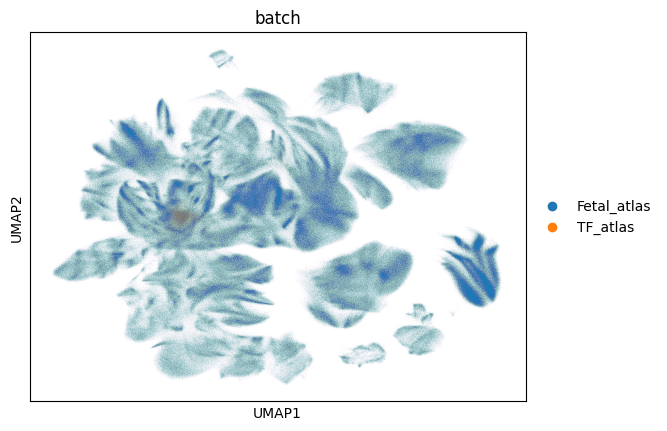

In [5]:
sc.pl.umap(integrated_adata, color='batch')

In [8]:
TF_atlas_cell_index = integrated_adata.obs.query("`batch` == 'TF_atlas'").index

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


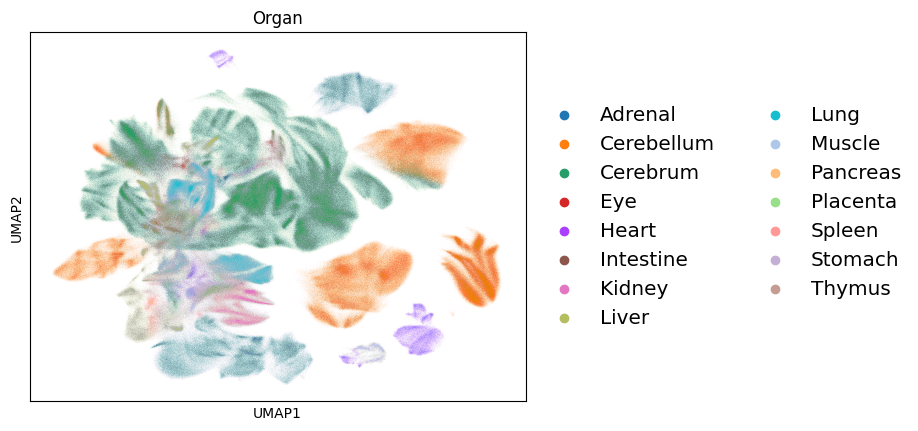

In [33]:
sc.pl.umap(integrated_Fetal, color='Organ',legend_fontsize='x-large')

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


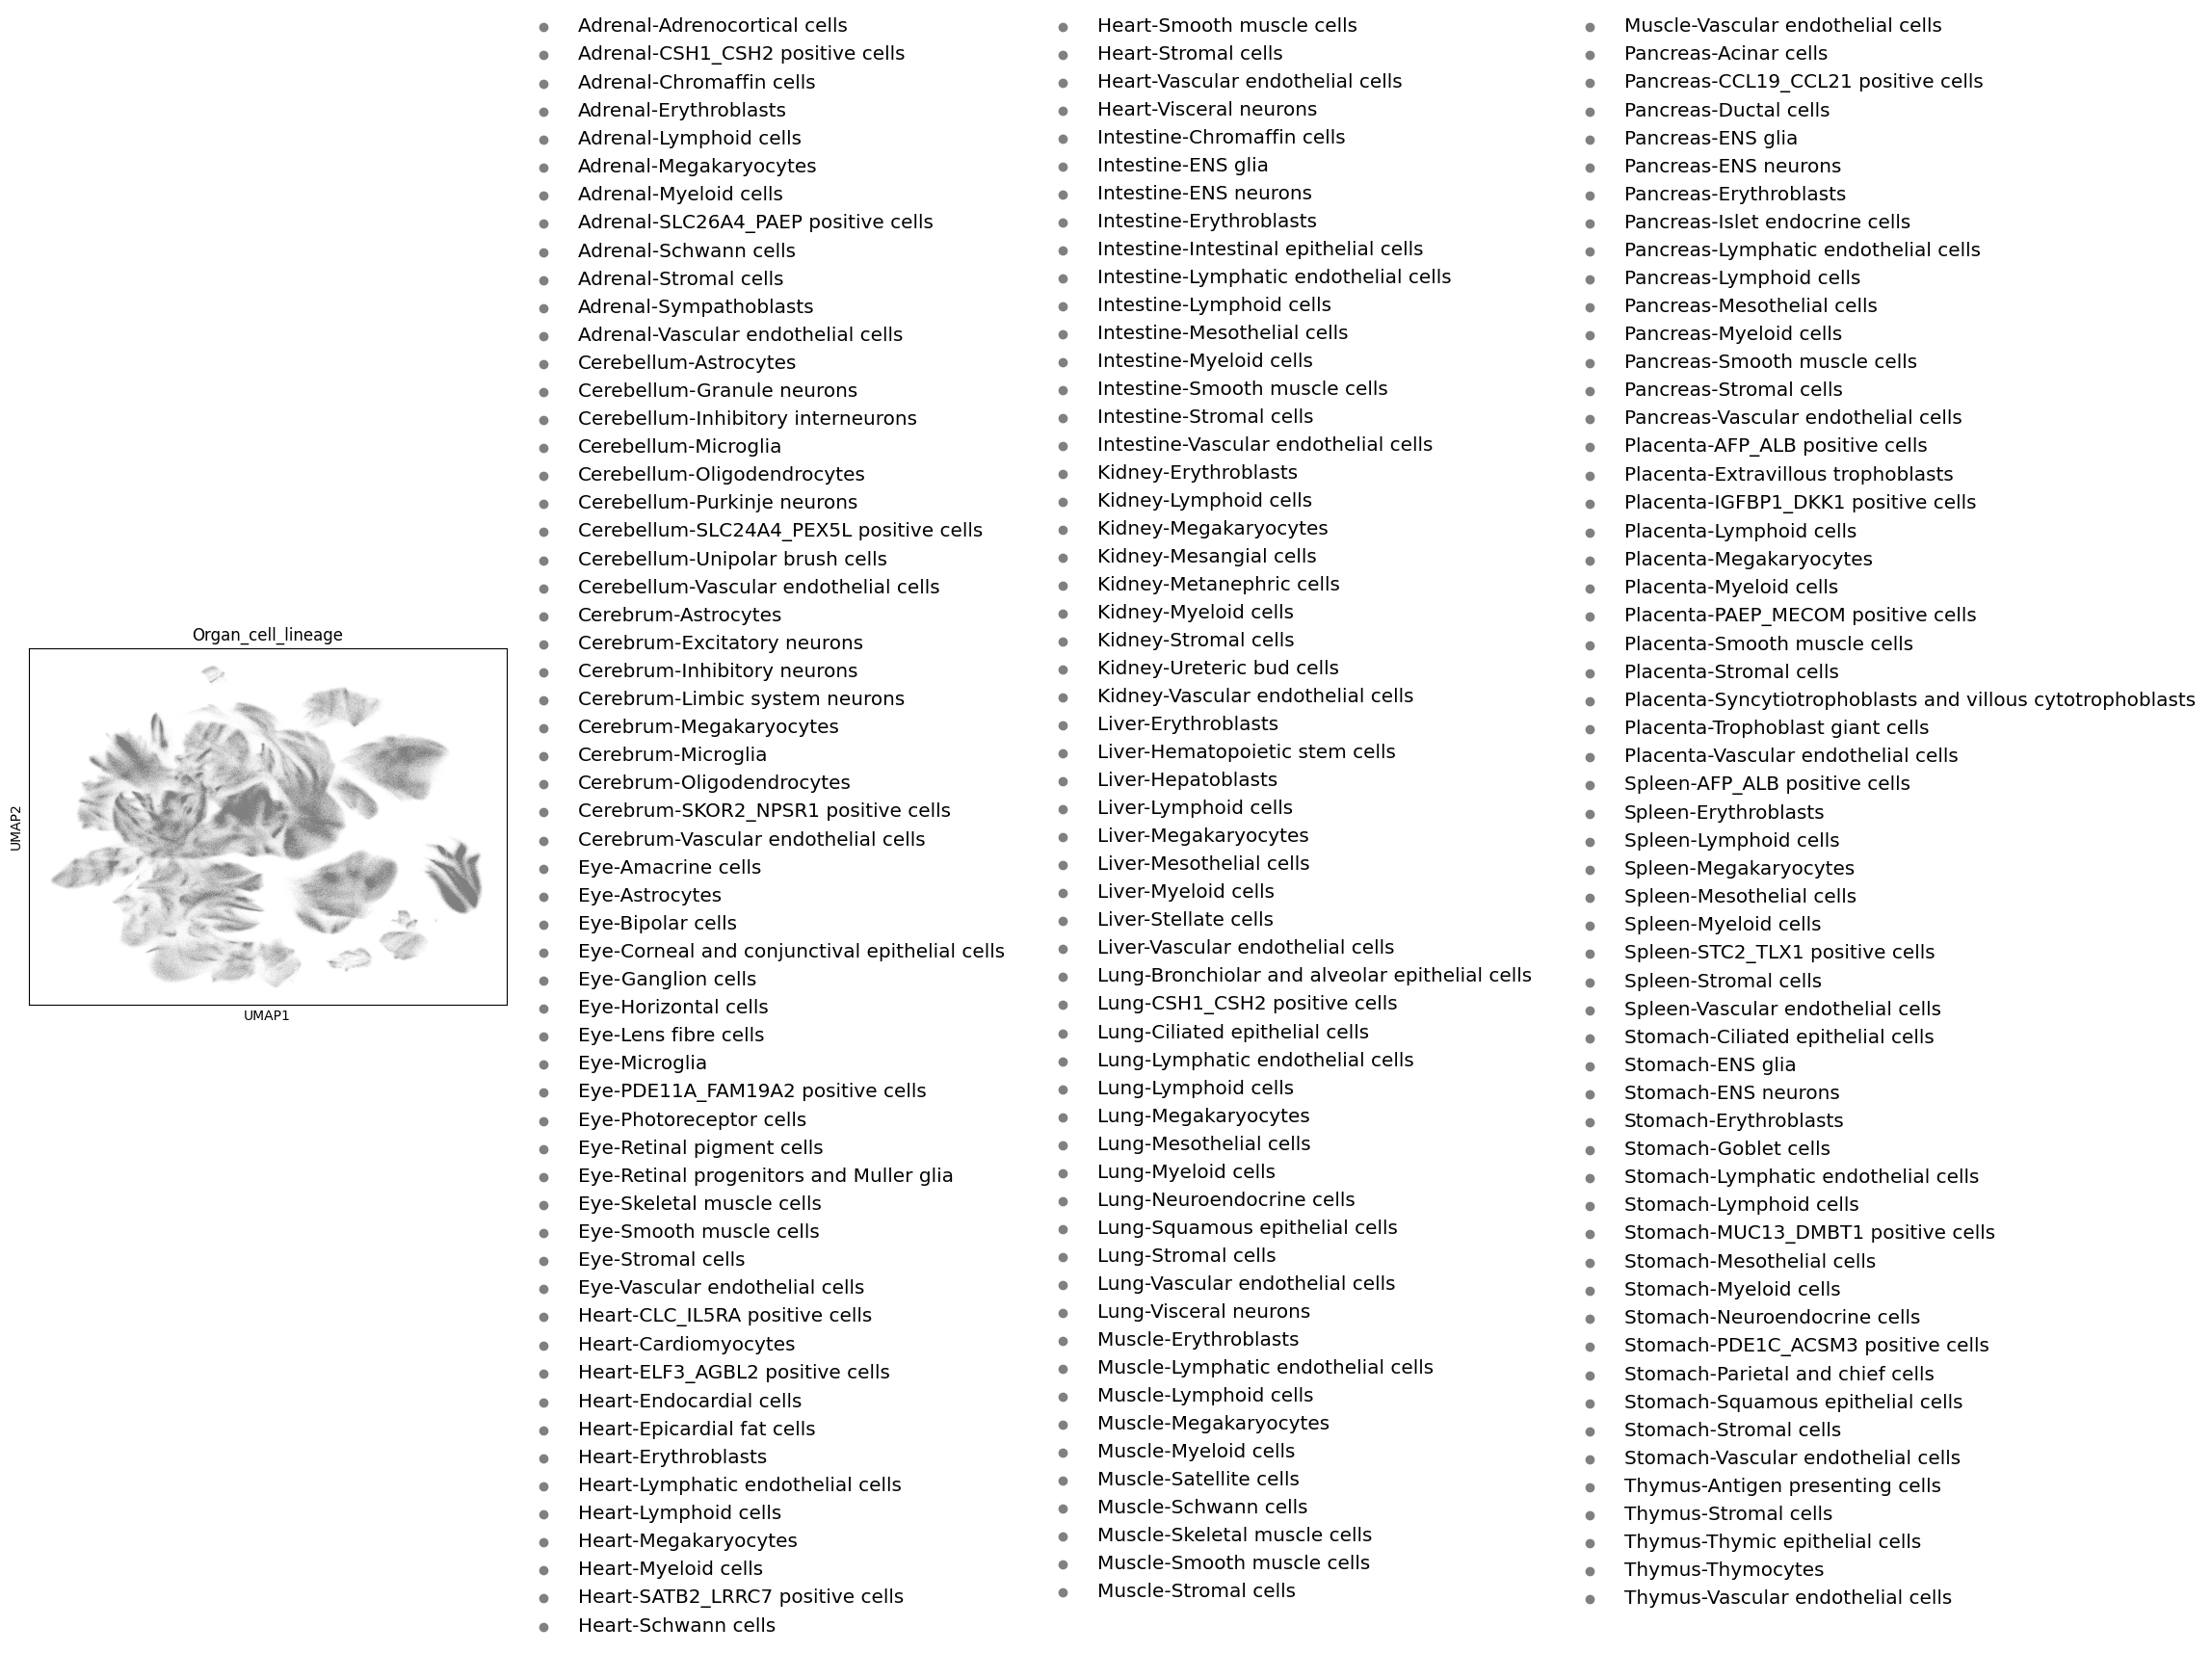

In [35]:
sc.pl.umap(integrated_Fetal, color='Organ_cell_lineage',legend_fontsize='x-large')

In [10]:
integrated_Fetal.obs_keys()

NameError: name 'integrated_Fetal' is not defined

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


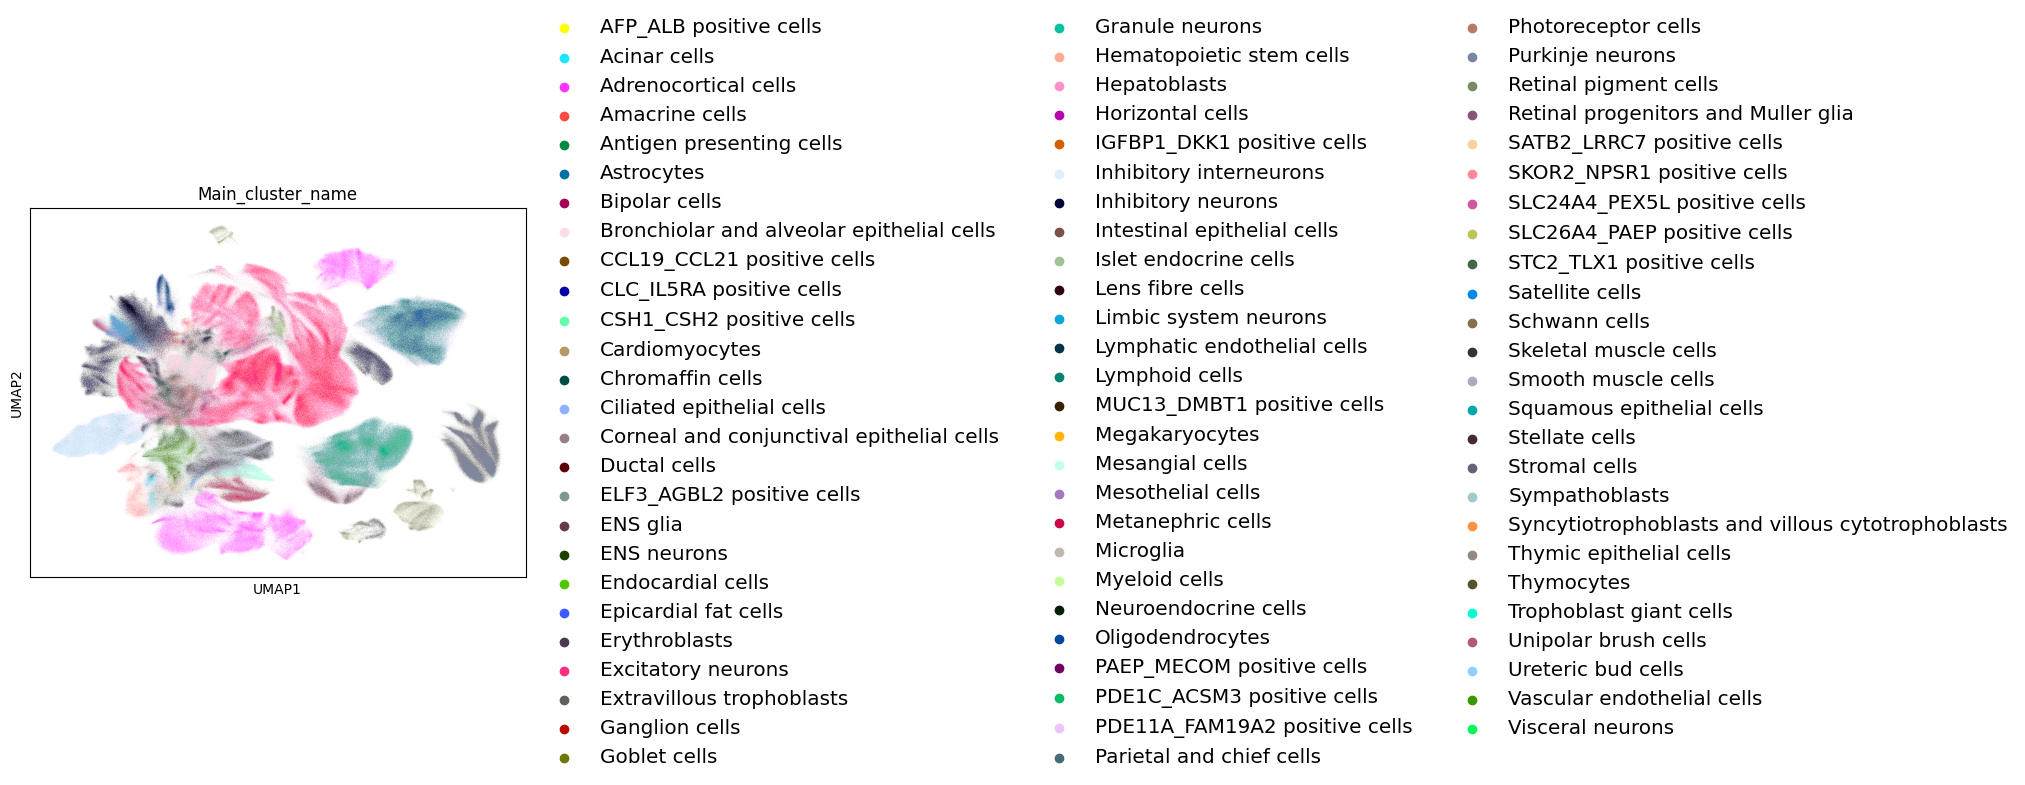

In [42]:
sc.pl.umap(integrated_Fetal, color='Main_cluster_name',legend_fontsize='x-large')

In [19]:
integrated_Fetal = integrated_adata[integrated_adata.obs['batch'] == 'Fetal_atlas'].copy()
integrated_TF = integrated_adata[integrated_adata.obs['batch'] == 'TF_atlas'].copy()

In [36]:
integrated_TF.shape

(28825, 1159)

In [39]:
integrated_Fetal.shape

(4062980, 1159)

In [40]:
sc.tl.ingest(integrated_TF, integrated_Fetal, obs='Organ_cell_lineage')

ValueError: all input arrays must have the same shape